### TODO: 
### Determine Learning Rate through a more used method (e.g. slope/minimum from 1 epoch grid search)




### 1. Loosen TR parameters until the loss is bad
### 2. Rerun with more epochs and fix batch size
### 3. Then mess with the subsample factor, and maybe the interpolation too.

In [17]:
import time
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt

# import src.learning_gradient_flow.gradient_flow_optimizer as gradient_flow_optimizer
from learning_gradient_flow import gradient_flow_optimizer, adam_flow_optimizer, sindy_tools

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = 'cpu'
print(f"Using device: {device}")
torch.manual_seed(0)

def get_flattened_parameters(model: nn.Module) -> torch.Tensor:
    params = []
    for p in model.parameters():
        params.append(p.data.clone().view(-1))
    return torch.cat(params)

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 8),
            nn.Tanh(),
            nn.Linear(8, 1)
        )
    def forward(self, x):
        return self.layers(x)

model = SimpleNet().to(device)

def true_fcn(x):
    return torch.sin(x * np.pi).to(device)

n_data = 500
nl = 0.2
x = 2 * torch.rand(n_data, 1).to(device) - 1
y = true_fcn(x) + nl * torch.randn_like(x)

# print n params
n_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {n_params}")

Using device: cpu
Number of parameters: 25


In [18]:
import lr_finder

# Training loop
batch_size = n_data
# batch_size = n_data // 10
# data loader
train_dataset = torch.utils.data.TensorDataset(x, y)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
n_batches = len(train_loader)

# criterion = nn.MSELoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-6)
# lr_finder = lr_finder.LRFinder(model, optimizer, criterion, device="cuda")
# lr_finder.range_test(train_loader, start_lr=1e-6, end_lr=1e1, num_iter=1000, accumulation_steps=1)
# ax, lr_suggested = lr_finder.plot()  # to inspect the loss-learning rate graph
# lr_finder.reset()  # to reset the model and optimizer to their initial state

Epoch 1/5000, Loss: Adam: 0.472040, Learned Adam ODE: 0.472040, Learned Adam ODE TR: 0.472040
Epoch 2/5000, Loss: Adam: 0.467604, Learned Adam ODE: 0.467604, Learned Adam ODE TR: 0.467604
Epoch 3/5000, Loss: Adam: 0.463237, Learned Adam ODE: 0.463237, Learned Adam ODE TR: 0.463237
Epoch 4/5000, Loss: Adam: 0.458940, Learned Adam ODE: 0.458942, Learned Adam ODE TR: 0.458942
Epoch 5/5000, Loss: Adam: 0.454715, Learned Adam ODE: 0.454719, Learned Adam ODE TR: 0.454719
Epoch 6/5000, Loss: Adam: 0.450562, Learned Adam ODE: 0.450569, Learned Adam ODE TR: 0.450569
Epoch 7/5000, Loss: Adam: 0.446482, Learned Adam ODE: 0.446494, Learned Adam ODE TR: 0.446494
Epoch 8/5000, Loss: Adam: 0.442476, Learned Adam ODE: 0.442493, Learned Adam ODE TR: 0.442493
Epoch 9/5000, Loss: Adam: 0.438544, Learned Adam ODE: 0.438567, Learned Adam ODE TR: 0.438567
Epoch 10/5000, Loss: Adam: 0.434688, Learned Adam ODE: 0.434716, Learned Adam ODE TR: 0.434716
Epoch 11/5000, Loss: Adam: 0.430906, Learned Adam ODE: 0.43

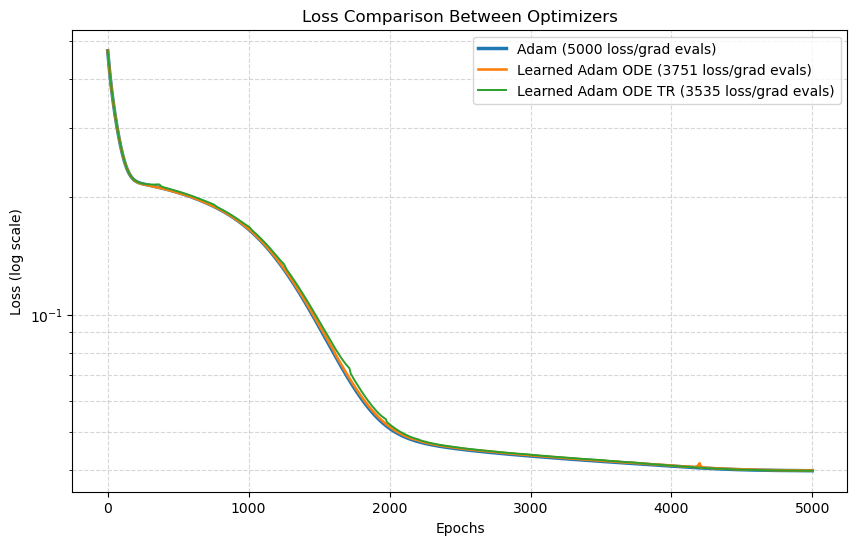

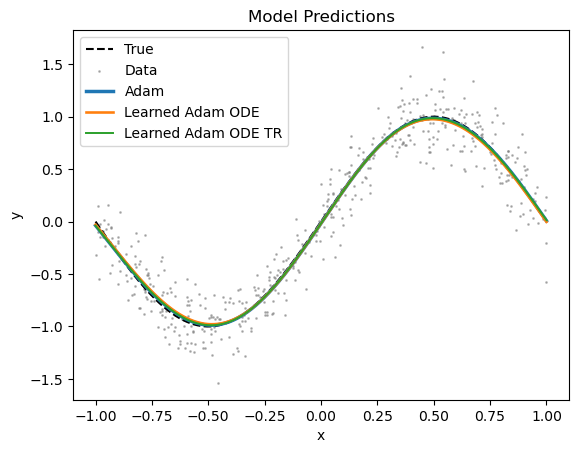

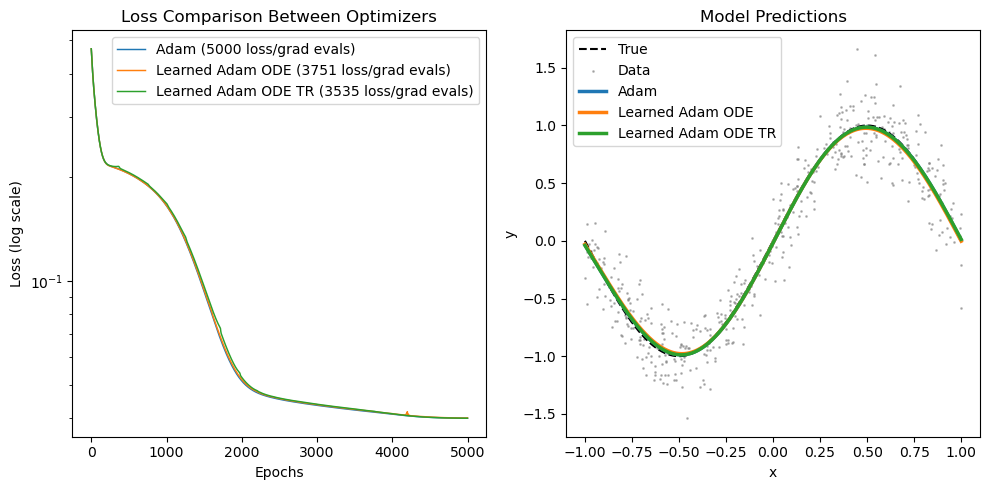

In [19]:

optimizer_names = [
                    # 'adam_torch',
                    'Adam',
                    # 'adam_ode',
                    'Learned Adam ODE',
                    'Learned Adam ODE TR',
                    # 'adam_torch_10x',
                    # 'adam_custom_10x',
                    # 'adam_ode_10x',
                    # 'adam_ode_learned_10x'
                  ]
optimizers = {}
for opt_name in optimizer_names:
    optimizers[opt_name] = {
        'model': SimpleNet().to(device),
        'optimizer': None,
        'losses': [],
        'param_history': []
    }


betas = (0.9, 0.999)
lr = 0.001
# lr = lr_suggested / 10
same_time = False

solver_fn = sindy_tools.dense_solver
solver_params = None
# solver_fn = sindy_tools.stls_sparse_solver
# solver_params = sindy_tools.SparseSolverParams(threshold=0.0, normalize_columns=False)
sindy_params = sindy_tools.SINDyParams(poly_order=2, include_bias=True,
                                       solver_fn=solver_fn, solver_params=solver_params)
# sindy_params = sindy_tools.SINDyParams(poly_order=4, include_bias=True)

# works for no mini batch
if lr == 0.001:
    if n_batches == 1:
        trc = adam_flow_optimizer.TrustRegionControl(
            cosine_similarity_good_threshold=0.7,
            cosine_similarity_bad_threshold=0.2,
            radius_factor_good=1.7,
            radius_factor_okay=0.9,
            radius_factor_bad=0.6,
            max_radius=0.5
        )
        history_size = 150
        retrain_interval = 200
        epochs = 5000
    else:
        # Final?
        trc = adam_flow_optimizer.TrustRegionControl(
            cosine_similarity_good_threshold=0.4,
            cosine_similarity_bad_threshold=0.1,
            # cosine_similarity_good_threshold=0.2,
            # cosine_similarity_bad_threshold=-0.1,
            radius_factor_good=1.7,
            radius_factor_okay=0.9,
            radius_factor_bad=0.6,
            max_radius=0.5
        )
        history_size = 150
        retrain_interval = 200
        epochs = 2500
else:
    # trc = adam_flow_optimizer.TrustRegionControl(
    #     cosine_similarity_good_threshold=0.9,
    #     cosine_similarity_bad_threshold=0.7,
    #     radius_factor_good=1.5,
    #     radius_factor_okay=0.4,
    #     radius_factor_bad=0.2,
    #     max_radius=0.5
    # )
    # history_size = 150
    # retrain_interval = 200
    # epochs = 10000
    trc = adam_flow_optimizer.TrustRegionControl(
    )
    history_size = 150 # likely make this a little bigger
    retrain_interval = 200
    epochs = 1000


# trc = adam_flow_optimizer.TrustRegionControl(
#     cosine_similarity_good_threshold=0.1,
#     cosine_similarity_bad_threshold=-0.3,
#     radius_factor_good=1.6,
#     radius_factor_okay=0.9,
#     radius_factor_bad=0.6,
#     max_radius=0.5
# )
subsample_factor = 10
# optimizers['adam_torch']['optimizer'] = torch.optim.Adam(
#     optimizers['adam_torch']['model'].parameters(), lr=lr, betas=betas)
optimizers['Adam']['optimizer'] = adam_flow_optimizer.CustomAdam(
    optimizers['Adam']['model'].parameters(), lr=lr, betas=betas)
# optimizers['adam_ode']['optimizer'] = adam_flow_optimizer.AdamEuler(
#     optimizers['adam_ode']['model'].parameters(), lr=lr, betas=betas)
optimizers['Learned Adam ODE']['optimizer'] = adam_flow_optimizer.AdamEulerLearned(
    optimizers['Learned Adam ODE']['model'].parameters(), lr=lr, betas=betas,
    history_size=history_size, retrain_interval=retrain_interval, sindy_params=sindy_params,
    subsample_factor=subsample_factor,
    points_added=0
    # debug=True
)
optimizers['Learned Adam ODE TR']['optimizer'] = adam_flow_optimizer.AdamEulerLearnedTR(
    optimizers['Learned Adam ODE TR']['model'].parameters(), lr=lr, betas=betas,
    history_size=history_size, trust_region_control=trc, sindy_params=sindy_params,
    gamma_tr_radius=None,
    use_data_driven_thresh=True,
    subsample_factor=subsample_factor,
    points_added=0
    # debug=True
)


# ensure all start at the same parameters (just use the first model)
# But add random noise to custom_adam2
for opt_name, opt_data in optimizers.items():
    name0 = optimizer_names[0]
    if opt_name != name0:
        opt_data['model'].load_state_dict(optimizers[name0]['model'].state_dict())
    # if opt_name != 'gradient_flow':
    #     opt_data['model'].load_state_dict(optimizers['gradient_flow']['model'].state_dict())
    opt_data['param_history'].append(get_flattened_parameters(opt_data['model']))


def create_closure(model, optimizer, x_batch, y_batch):
    def closure():
        optimizer.zero_grad()
        output = model(x_batch)  # Uses global x, y data
        loss = torch.mean((output - y_batch)**2)
        loss.backward()
        return loss
    return closure

for epoch in range(epochs):
    # Train each optimizer for one step
    for opt_name, opt_data in optimizers.items():
        loss = 0.0
        model = opt_data['model']
        optimizer = opt_data['optimizer']

        # Create closure for this model/optimizer
        for x_batch, y_batch in train_loader:
            closure_fn = create_closure(model, optimizer, x_batch, y_batch)
            if 'adam_ode' in opt_name:
                loss = loss + optimizer.step(closure_fn, same_time=same_time).item()
            else:
                loss = loss + optimizer.step(closure_fn).item()

        # Store results
        opt_data['losses'].append(loss)
        opt_data['param_history'].append(get_flattened_parameters(model))

    # Print progress
    if epoch < 20 or epoch % (epochs // 20) == 0 or epoch == epochs - 1:
        status = ", ".join([f"{name}: {data['losses'][-1]:.6f}" for name, data in optimizers.items()])
        print(f"Epoch {epoch+1}/{epochs}, Loss: {status}")


for opt_name, opt_data in optimizers.items():
    # get number of evals, and record them. We will put them in legend
    if hasattr(opt_data['optimizer'], 'state'):
        func_evals = opt_data['optimizer'].state.get('func_evals', None)
        if func_evals is not None:
            opt_data['func_evals'] = func_evals
        else:
            opt_data['func_evals'] = epochs*n_batches
    else:
        opt_data['func_evals'] = epochs*n_batches

colors = [f'C{i%4}' for i in range(len(optimizers))]
linestyles = ['-']*4 + [':']*4

# Plot loss curves
plt.figure(figsize=(10, 6))
lw_factor = 2.5
for i, (opt_name, opt_data) in enumerate(optimizers.items()):
    label = f'{opt_name} ({opt_data["func_evals"]} loss/grad evals)'
    plt.semilogy(opt_data['losses'], label=label, linewidth=lw_factor,
                 color=colors[i], linestyle=linestyles[i])
    lw_factor *= 0.75
plt.xlabel('Epochs')
plt.ylabel('Loss (log scale)')
plt.title('Loss Comparison Between Optimizers')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
# save fig

t = time.strftime("%m-%d_%H-%M")

plt.savefig(
    f'figs/adam_final/batches_{n_batches}_epochs_{epochs}_hs_rt_{history_size}_{retrain_interval}_loss_{t}.png',
    dpi=300, bbox_inches='tight')

# compare on data
x_eval = torch.linspace(-1, 1, 1000).view(-1, 1).to(device)
y_eval = true_fcn(x_eval).to(device)
y_eval_preds = {}
for opt_name, opt_data in optimizers.items():
    with torch.no_grad():
        y_eval_preds[opt_name] = opt_data['model'](x_eval)
plt.figure()
lw_factor = 2.5
plt.plot(x_eval.cpu(), y_eval.cpu(), 'k--', label='True')
plt.scatter(x.cpu(), y.cpu(), color='gray', alpha=0.5, label='Data', s=1)
for i, (opt_name, y_eval_pred) in enumerate(y_eval_preds.items()):
    plt.plot(x_eval.cpu(), y_eval_pred.cpu(), label=opt_name, linewidth=lw_factor,
             color=colors[i], linestyle=linestyles[i])
    lw_factor *= 0.75
plt.title('Model Predictions')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.savefig(
    f'figs/adam_final/batches_{n_batches}_epochs_{epochs}_hs_rt_{history_size}_{retrain_interval}_prediction_{t}.png',
    dpi=300, bbox_inches='tight')


fig, axs = plt.subplots(1, 2, figsize=(10, 5))
for i, (opt_name, opt_data) in enumerate(optimizers.items()):
    label = f'{opt_name} ({opt_data["func_evals"]} loss/grad evals)'
    axs[0].semilogy(opt_data['losses'], label=label, linewidth=lw_factor,
                    color=colors[i], linestyle=linestyles[i])

axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss (log scale)')
axs[0].set_title('Loss Comparison Between Optimizers')
# axs[0].grid(True, which='both', linestyle='--', alpha=0.5)
axs[0].legend([f'{name} ({data["func_evals"]} loss/grad evals)' for name, data in optimizers.items()])

axs[1].plot(x_eval.cpu(), y_eval.cpu(), 'k--', label='True')
axs[1].scatter(x.cpu(), y.cpu(), color='gray', alpha=0.5, label='Data', s=1)
for i, (opt_name, y_eval_pred) in enumerate(y_eval_preds.items()):
    axs[1].plot(x_eval.cpu(), y_eval_pred.cpu(), label=opt_name, linewidth=2.5,
                color=colors[i], linestyle=linestyles[i])
axs[1].set_title('Model Predictions')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].legend()

plt.tight_layout()
plt.savefig(
    f'figs/adam_final/batches_{n_batches}_epochs_{epochs}_hs_rt_{history_size}_{retrain_interval}_combined_{t}.png',
    dpi=300, bbox_inches='tight')

In [20]:
# Compute l2 error from the true function
l2_errors = {}
for opt_name, y_eval_pred in y_eval_preds.items():
    l2_error = torch.norm(y_eval_pred - y_eval, p=2) / torch.norm(y_eval, p=2)
    l2_error = l2_error.item()
    print(f"Relative l2 error for {opt_name}: {l2_error:.6f}")
    l2_errors[opt_name] = l2_error

Relative l2 error for Adam: 0.021092
Relative l2 error for Learned Adam ODE: 0.030335
Relative l2 error for Learned Adam ODE TR: 0.021686


<!-- Add vertical spacing in md through html -->

<div style="margin-bottom: 1000px;"></div>

# Selected Results

### Points added: 9 (interpolate to get factor of 10 smaller step size)
![alt text](7a2d406d-3584-4ae2-9169-6834d3719aa8.png)

### Points added: 0 (default)
![alt text](de7e032b-3a04-4b57-9664-13b2b3cd024a.png)

### Interpolation Verification

In [21]:
opt = optimizers['adam_ode_learned_tr']['optimizer']
# opt = optimizers['adam_ode_learned']['optimizer']

points_added = 9

x_old = torch.stack(opt.state['history'], dim=0)  # history_size, num_params
print(len(opt.state['history']))
x = opt.interpolate(x_old, points_added=points_added, order=2)
print(x_old.shape)

lhs_target_old = torch.stack(opt.state['grad_history'], dim=0)
lhs_target = opt.interpolate(lhs_target_old, points_added=points_added, order=1)

t_span_old = torch.arange(x_old.shape[0])
dt_intp = 1.0 / (1 + points_added)
t_span = torch.arange(x.shape[0]) * dt_intp

# show the with and without interpolation, 2 subplots
plt.figure(figsize=(15, 20))
plt.subplot(2, 1, 1)
for i in range(x_old.shape[1]):
    plt.scatter(t_span_old, x_old[:, i], label=f'Param {i+1}', s=10, marker='x')
    plt.scatter(t_span, x[:, i], label=f'Interpolated Param {i+1}', s=1, marker='.')

plt.subplot(2, 1, 2)
for i in range(lhs_target_old.shape[1]//3):
    plt.scatter(t_span_old, lhs_target_old[:, i], label=f'Grad {i+1}', s=10, marker='x')
    plt.scatter(t_span, lhs_target[:, i], label=f'Interpolated Grad {i+1}', s=1, marker='.')


KeyError: 'adam_ode_learned_tr'

<Figure size 1000x600 with 1 Axes>